<a href="https://colab.research.google.com/github/HUISMI/mldl-odyssey/blob/main/1.%20data-preprocessing/fish_analysis_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#K-Nearest Neighbors을 사용한 물고기 예측 모델 v1
- Data Scailing: 표준점수 사용
  - 표준점수 = ((데이터) - (평균)) / (표준편차)

In [42]:
import pandas as pd

file_path = '/content/drive/MyDrive/colab_notes/mldl-odyssey/datasets/Fish.csv'

df = pd.read_csv(file_path)
df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


## 1. Species(bream&smelt), Weight, Length2 추출 및 데이터프레임 만들기
- version1에선 빙어와 도미, 무게와 길이만 사용하도록 한다.

In [12]:
# 대괄호를 두 번 사용 -> 결과가 표 형태로 나오기 때문.
fish_subset = df[df['Species'].isin(['Bream', 'Smelt'])][['Species', 'Weight', 'Length2']]

display(fish_subset.head())
display(fish_subset.shape)
display(fish_subset['Species'].value_counts())

,Species,Weight,Length2
0,Bream,242.0,25.4
1,Bream,290.0,26.3
2,Bream,340.0,26.5
3,Bream,363.0,29.0
4,Bream,430.0,29.0


(49, 3)

,count
Species,
Bream,35
Smelt,14


In [14]:
import numpy as np

넘파이배열 만들기

In [11]:
fish_data = np.column_stack((fish_subset['Length2'], fish_subset['Weight']))

display(fish_data[:5])
fish_data.shape

array([[ 25.4, 242. ],
       [ 26.3, 290. ],
       [ 26.5, 340. ],
       [ 29. , 363. ],
       [ 29. , 430. ]])

(49, 2)

정답 배열 만들기

In [13]:
fish_target = np.concatenate((np.ones(35), np.zeros(14)))

## 2. 사이킷런으로 훈련 세트와 테스트 세트 분할

In [15]:
from sklearn.model_selection import train_test_split

샘플링 편향을 방지하기 위해 클래스 비율에 맞게 데이터 분할 (stratify)

In [18]:
train_input, test_input, train_target, test_target = train_test_split(fish_data, fish_target, stratify=fish_target, random_state=42)

test_target

array([0., 0., 1., 0., 1., 0., 1., 1., 1., 1., 1., 1., 1.])

## 3. K-최근접 이웃 모델로 훈련 후 1차 점검

In [24]:
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

In [22]:
kn = KNeighborsClassifier()
kn.fit(train_input, train_target)
kn.score(test_input, test_target)

1.0

새로운 데이터로 모델이 예측을 잘하는지 평가하기
- 예측해야하는 new 데이터는 smelt(빙어, 0)가 아닌 bream(도미 ,1)

In [23]:
# 사이킷런 모델은 항상 2차원 배열만 받는다!
kn.predict([[25, 150]])

array([0.])

ㄴ smelt(0)으로 잘못 예측!!

In [28]:
# 근접 이웃 5개 거리와 인덱스 추출
distances, indexes = kn.kneighbors([[25,150]])

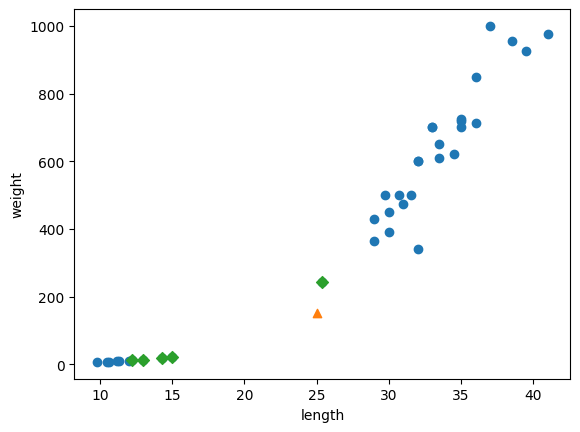

In [29]:
# 산점도는 코드 여러개 붙이면 같이 표시됨
plt.scatter(train_input[:,0], train_input[:,1])
plt.scatter(25, 150, marker='^')
plt.scatter(train_input[indexes, 0], train_input[indexes, 1], marker='D')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [30]:
distances

array([[ 92.00086956, 130.48375378, 130.73859415, 138.32150953,
        138.39320793]])

위와 같이 거리를 바탕으로한 이웃 선정이 우리의 직관과 다른 현상 발생

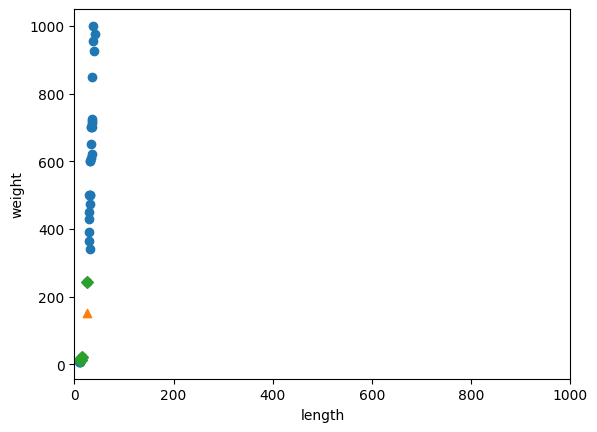

In [33]:
plt.scatter(train_input[:,0], train_input[:,1])
plt.scatter(25, 150, marker='^')
plt.scatter(train_input[indexes, 0], train_input[indexes, 1], marker='D')
plt.xlim((0, 1000))
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

사실상 y축인 weight에 의해서만 영향을 받고 있다는 것을 알 수 있다.<br>
-> 스케일링 필요

## 4. 전처리 및 다시 훈련하기!

In [35]:
mean = np.mean(train_input, axis=0)
std = np.std(train_input, axis=0)

display(mean, std)

array([ 27.29722222, 454.09722222])

array([  9.98244253, 323.29893931])

표준점수 만들기!

In [37]:
# numpy의 브로드캐스팅으로 모든 행에 대해 계산 처리
train_scaled = (train_input - mean) / std
test_scaled = (test_input - mean) / std
new_scaled = ([25, 150] - mean) / std

In [39]:
kn.fit(train_scaled, train_target)
kn.score(test_scaled, test_target)

1.0

In [40]:
kn.predict([new_scaled])

array([1.])

SUCCESS!! 이제 산점도 확인

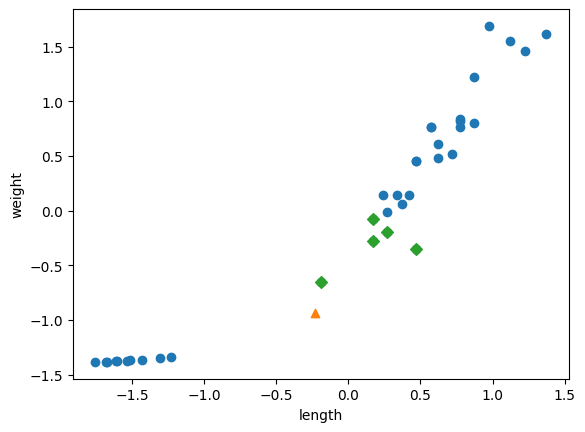

In [41]:
distances, indexes = kn.kneighbors([new_scaled])

plt.scatter(train_scaled[:,0], train_scaled[:,1])
plt.scatter(new_scaled[0], new_scaled[1], marker='^')
plt.scatter(train_scaled[indexes, 0], train_scaled[indexes, 1], marker='D')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

성공적으로 마무리되었다.